In [5]:
import sys
import os
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "..")) if "src" not in os.listdir(current_dir) else current_dir

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.behavioral_models.base_cpr_calculator import BaseCPRCalculator
from src.behavioral_models.prepayment_calibrator import HybridPrepaymentCalibrator
from src.alm_engine.yield_curve import YieldCurve
from src.alm_engine.instruments import RetailMortgage
from src.alm_engine.engine import ALMEngine

In [7]:
calculator = BaseCPRCalculator(random_seed=42)
raw_tape = calculator.simulate_servicing_tape(num_records=25000)
tape_with_smm = calculator.calculate_loan_level_smm(raw_tape)

base_cpr = calculator.extract_base_cpr(tape_with_smm)
calibrator = HybridPrepaymentCalibrator(base_cpr=base_cpr)
hybrid_model = calibrator.fit_model(tape_with_smm)

print(f"Calibration complete: {hybrid_model}")

Calibration complete: HybridPrepaymentModel(S-Curve Max=0.48, ML_Residuals=Active)


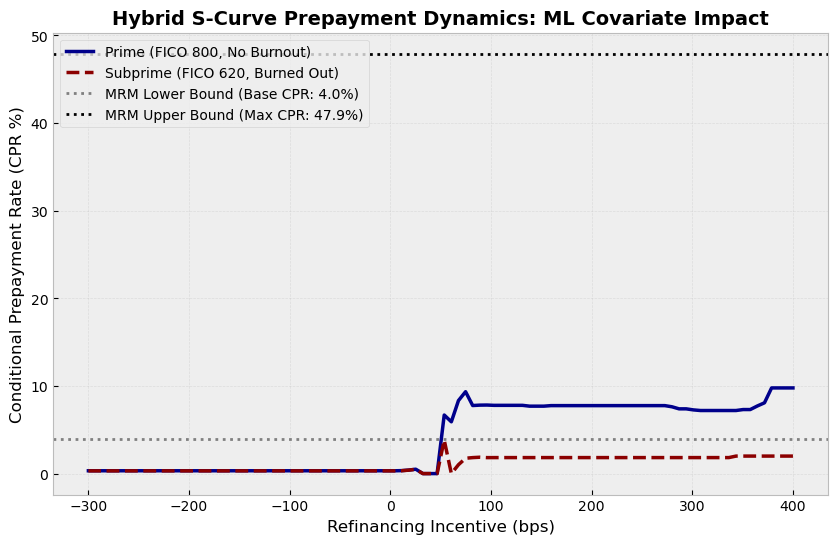

In [9]:
contractual_rate = 0.05
market_rates = np.linspace(0.01, 0.08, 100)
incentives = contractual_rate - market_rates

prime_cprs = [hybrid_model.calculate_cpr(contractual_rate, mkt, fico=800, burnout=0) for mkt in market_rates]
subprime_cprs = [hybrid_model.calculate_cpr(contractual_rate, mkt, fico=620, burnout=1) for mkt in market_rates]

plt.figure(figsize=(10, 6))
plt.style.use('bmh')

plt.plot(incentives * 10000, np.array(prime_cprs) * 100, label="Prime (FICO 800, No Burnout)", color='darkblue', linewidth=2.5)
plt.plot(incentives * 10000, np.array(subprime_cprs) * 100, label="Subprime (FICO 620, Burned Out)", color='darkred', linewidth=2.5, linestyle='--')

plt.axhline(hybrid_model.base_cpr * 100, color='gray', linestyle=':', label=f'MRM Lower Bound (Base CPR: {hybrid_model.base_cpr*100:.1f}%)')
plt.axhline(hybrid_model.max_cpr *100, color='black', linestyle=':', label=f'MRM Upper Bound (Max CPR: {hybrid_model.max_cpr*100:.1f}%)')

plt.title('Hybrid S-Curve Prepayment Dynamics: ML Covariate Impact', fontsize=14, fontweight='bold')
plt.xlabel('Refinancing Incentive (bps)', fontsize=12)
plt.ylabel('Conditional Prepayment Rate (CPR %)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

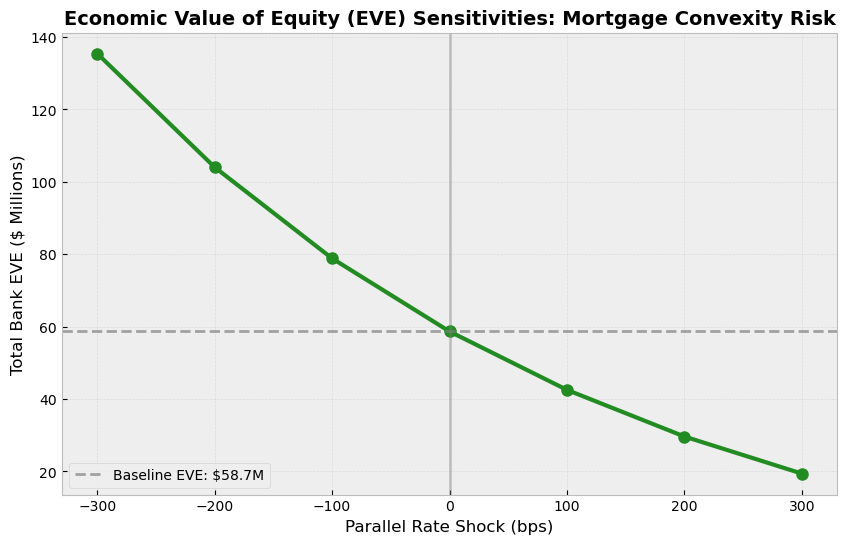

In [15]:
from src.alm_engine.instruments import TermDeposit

tenors = [0.0, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 30.0]
base_rates = [0.04] * len(tenors)
baseline_curve = YieldCurve(tenors, base_rates)

engine = ALMEngine(portfolio=[], baseline_curve=baseline_curve)

prime_mortgages = RetailMortgage(
    notional=100_000_000, rate=0.05, maturity=30.0,
    prepayment_model=hybrid_model, fico=800, burnout=0
)
subprime_mortgages = RetailMortgage(
    notional=100_000_000, rate=0.05, maturity=30.0,
    prepayment_model=hybrid_model, fico=620, burnout=1
)

deposits = TermDeposit(notional=-180_000_000, rate=0.02, maturity=5.0)

my_portfolio = [prime_mortgages, subprime_mortgages, deposits]
engine = ALMEngine(portfolio=my_portfolio, baseline_curve=baseline_curve)

shock_bps = [-300, -200, -100, 0, 100, 200, 300]
eve_results = []

for shock in shock_bps:
    shocked_rates = [max(r + (shock / 10000.0), 0.001) for r in base_rates]
    active_curve = YieldCurve(tenors, shocked_rates)

    eve = engine.calculate_eve(active_curve)
    eve_results.append(eve / 1_000_000)

plt.figure(figsize=(10, 6))
plt.style.use('bmh')

plt.plot(shocks_bps, eve_results, marker='o', markersize=8, color='forestgreen', linewidth=3)

base_eve = eve_results[shocks_bps.index(0)]
plt.axhline(base_eve, color='gray', linestyle='--', alpha=0.7, label=f'Baseline EVE: ${base_eve:.1f}M')
plt.axvline(0, color='gray', linestyle='-', alpha=0.4)

plt.title('Economic Value of Equity (EVE) Sensitivities: Mortgage Convexity Risk', fontsize=14, fontweight='bold')
plt.xlabel('Parallel Rate Shock (bps)', fontsize=12)
plt.ylabel('Total Bank EVE ($ Millions)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()